# Выбор локации для скважины

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

In [1]:
!pip install -U scikit-learn -q

In [2]:
pip install phik -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

#import warnings
#warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, root_mean_squared_error as RMSE

import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix

In [4]:
RANDOM_STATE = 127
TEST_SIZE = 0.25
state = np.random.RandomState(RANDOM_STATE)

## Загрузка и подготовка данных

### Загрузка данных

In [5]:
try:
    df_geo_data_0 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_0.csv', index_col='id')
except:
    print('Проблема загрузки данных')

df_geo_data_0.head()

,f0,f1,f2,product
id,,,,
txEyH,0.705745,-0.497823,1.221170,105.280062
2acmU,1.334711,-0.340164,4.365080,73.037750
409Wp,1.022732,0.151990,1.419926,85.265647
iJLyR,-0.032172,0.139033,2.978566,168.620776
Xdl7t,1.988431,0.155413,4.751769,154.036647


In [6]:
df_geo_data_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, txEyH to 1CWhH
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   f0       100000 non-null  float64
 1   f1       100000 non-null  float64
 2   f2       100000 non-null  float64
 3   product  100000 non-null  float64
dtypes: float64(4)
memory usage: 3.8+ MB


In [7]:
try:
    df_geo_data_1 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_1.csv', index_col='id')
except:
    print('Проблема загрузки данных')

df_geo_data_1.head()

,f0,f1,f2,product
id,,,,
kBEdx,-15.001348,-8.276000,-0.005876,3.179103
62mP7,14.272088,-3.475083,0.999183,26.953261
vyE1P,6.263187,-5.948386,5.001160,134.766305
KcrkZ,-13.081196,-11.506057,4.999415,137.945408
AHL4O,12.702195,-8.147433,5.004363,134.766305


In [8]:
df_geo_data_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, kBEdx to relB0
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   f0       100000 non-null  float64
 1   f1       100000 non-null  float64
 2   f2       100000 non-null  float64
 3   product  100000 non-null  float64
dtypes: float64(4)
memory usage: 3.8+ MB


In [9]:
try:
    df_geo_data_2 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_2.csv', index_col='id')
except:
    print('Проблема загрузки данных')

df_geo_data_2.head()

,f0,f1,f2,product
id,,,,
fwXo0,-1.146987,0.963328,-0.828965,27.758673
WJtFt,0.262778,0.269839,-2.530187,56.069697
ovLUW,0.194587,0.289035,-5.586433,62.871910
q6cA6,2.236060,-0.553760,0.930038,114.572842
WPMUX,-0.515993,1.716266,5.899011,149.600746


In [10]:
df_geo_data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, fwXo0 to V9kWn
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   f0       100000 non-null  float64
 1   f1       100000 non-null  float64
 2   f2       100000 non-null  float64
 3   product  100000 non-null  float64
dtypes: float64(4)
memory usage: 3.8+ MB


### Анализ данных

In [11]:
df_geo_data_0.duplicated().sum()

0

In [12]:
df_geo_data_1.duplicated().sum()

0

In [13]:
df_geo_data_2.duplicated().sum()

0

В данных нет дубликатов.

In [14]:
df_geo_data_0.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


In [15]:
df_geo_data_1.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


In [16]:
df_geo_data_2.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


Для месторождений из geo_data_0 и geo_data_2 не наблюдается выбросов (среднее и медиана примерно одинаковы) и аномалий. Для месторождения из geo_data_1 у параметров f0 и f1 большие значения стандартных отклонений, необходимо проверить их распределение,а так же есть большая разница между средним и медианой параметра product, возможны выбросы.

In [17]:
def plot_box_hist(param, param_name, df):
    #построение ящика с усами
    plt.figure(figsize = (10.5, 2))
    plot_box = sns.boxplot(x=param)
    plt.title(f'Разброс значений параметра {param_name}')
    plt.show()
    #построение гистограммы
    plt.figure(figsize = (10, 6))
    plt.axvline(param.mean(), c='red', ls='-', lw=2.5, label='Среднее')
    plt.axvline(param.median(), c='green', ls='--', lw=2.5, label='Медиана')
    plt.legend()
    plot_hist = sns.histplot(data=df, x=param, stat='density', common_norm=False)
    plt.title(f'Распределение значений параметра {param_name}')
    plt.xlabel(f'{param_name}')
    plt.ylabel('Плотность распределения')
    plt.grid(axis='y')
    plt.show()
    return plot_box, plot_hist

**Распределения параметров для месторождения из файла geo_data_0:**

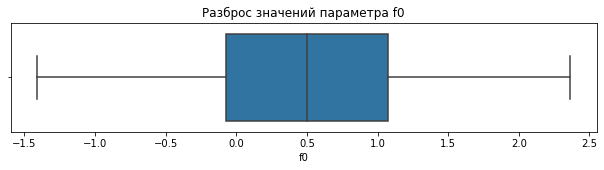

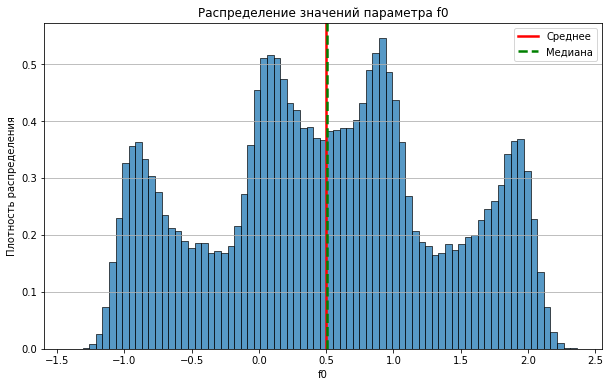

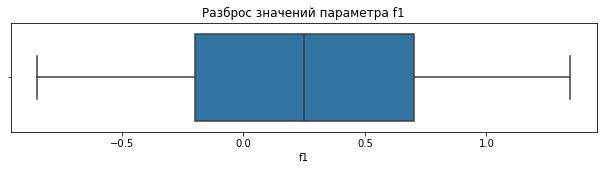

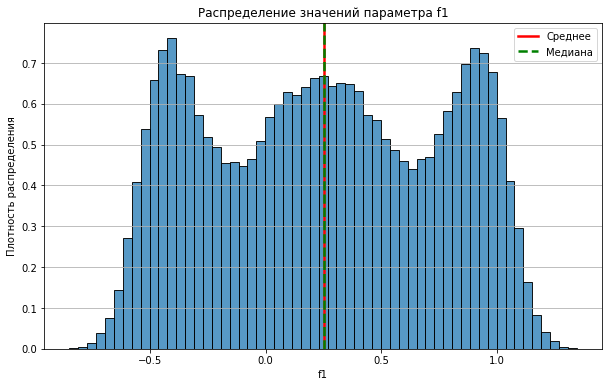

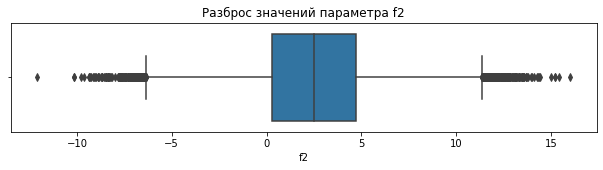

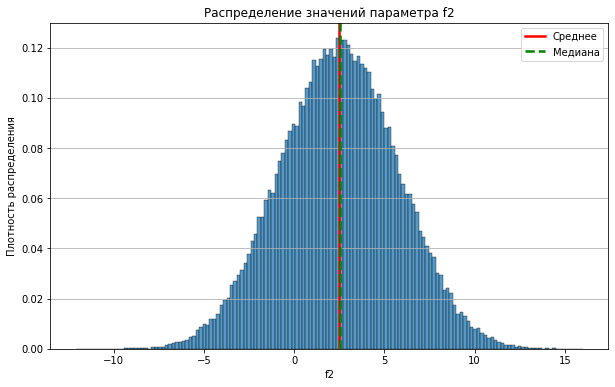

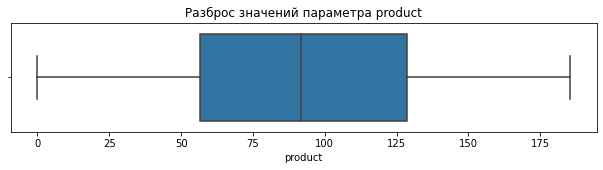

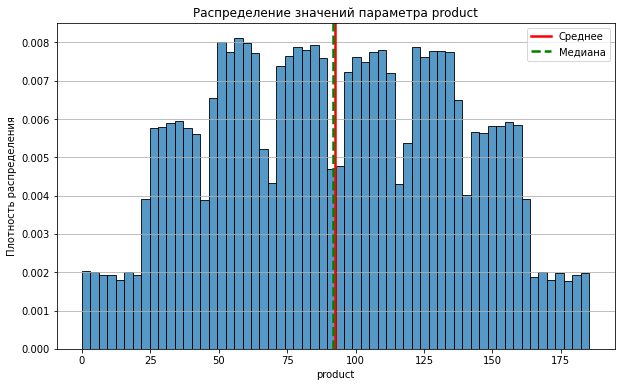

In [18]:
for column in df_geo_data_0.columns.tolist():
    plot_box_hist(df_geo_data_0[column], column, df_geo_data_0)

**Распределения параметров для месторождения из файла geo_data_1:**

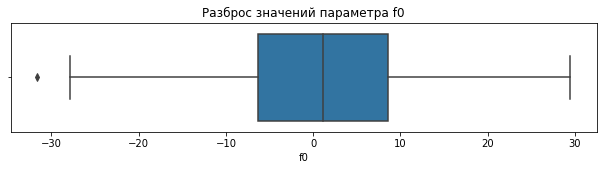

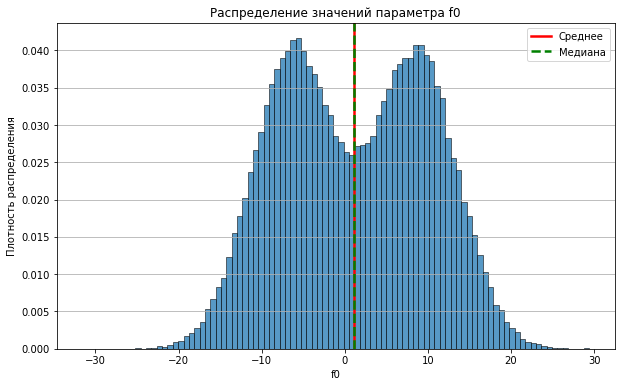

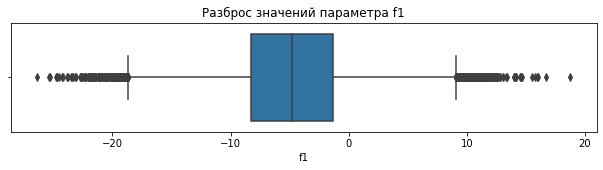

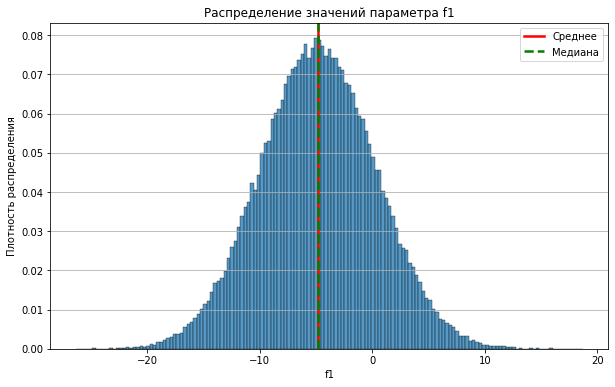

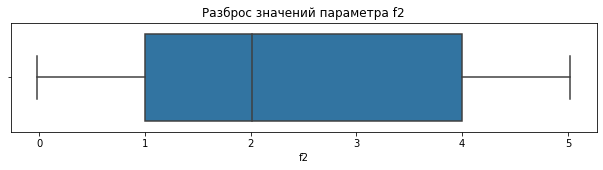

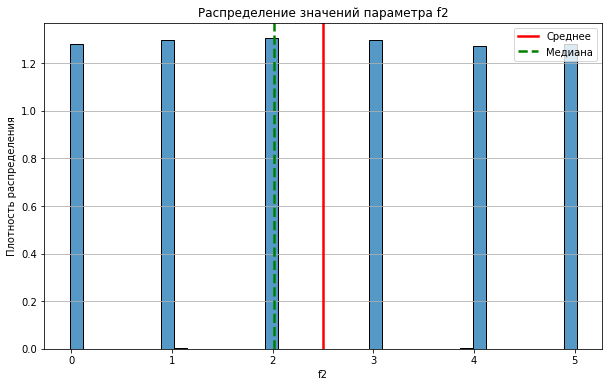

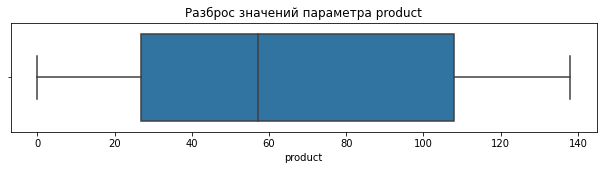

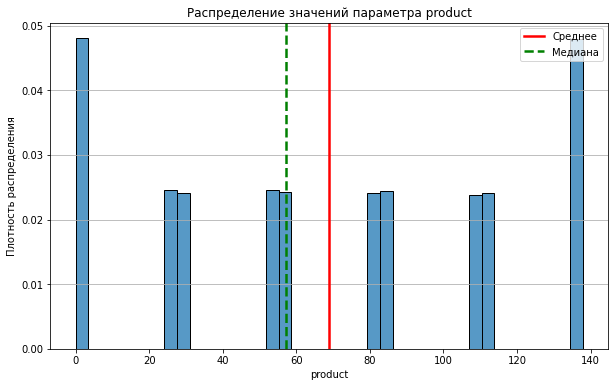

In [19]:
for column in df_geo_data_1.columns.tolist():
    plot_box_hist(df_geo_data_1[column], column, df_geo_data_1)

Значения параметров f2 и product для месторождения из файла geo_data_1 выглядят аномально дискретными.

**Распределения параметров для месторождения из файла geo_data_2:**

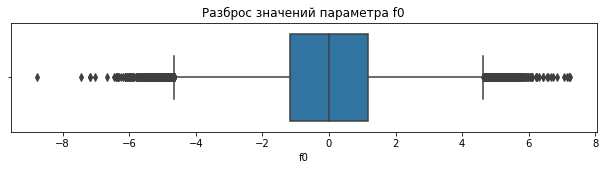

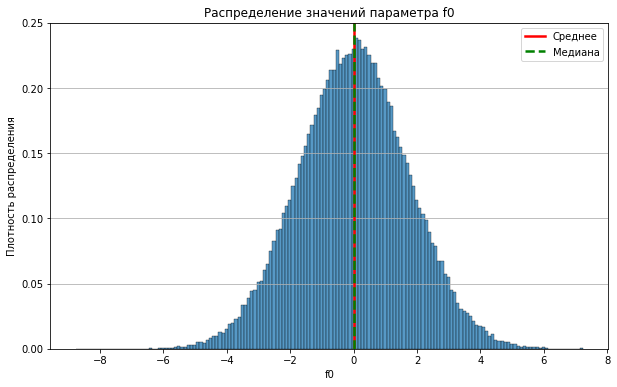

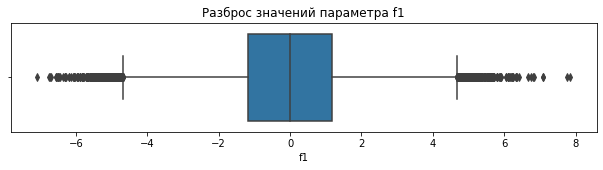

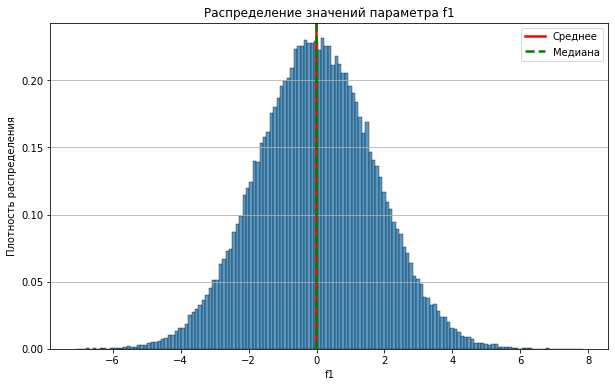

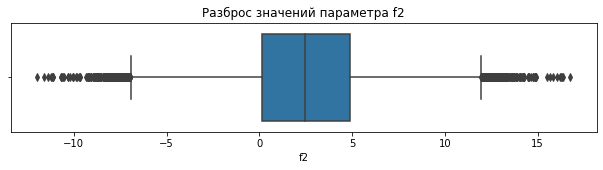

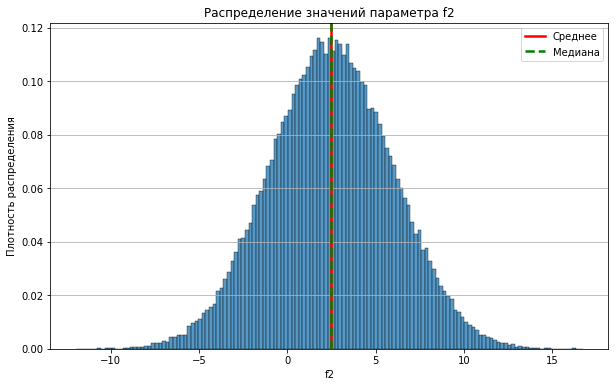

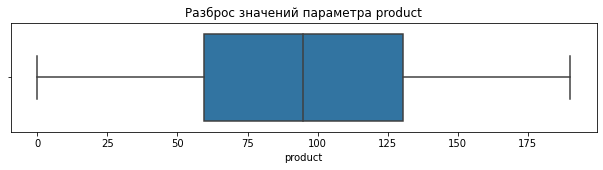

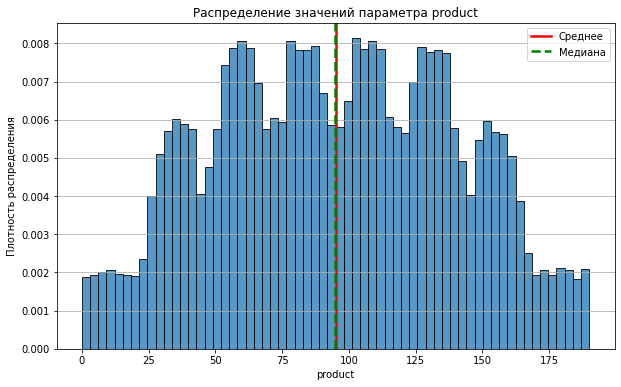

In [20]:
for column in df_geo_data_2.columns.tolist():
    plot_box_hist(df_geo_data_2[column], column, df_geo_data_2)

График отношения параметров месторождения 0


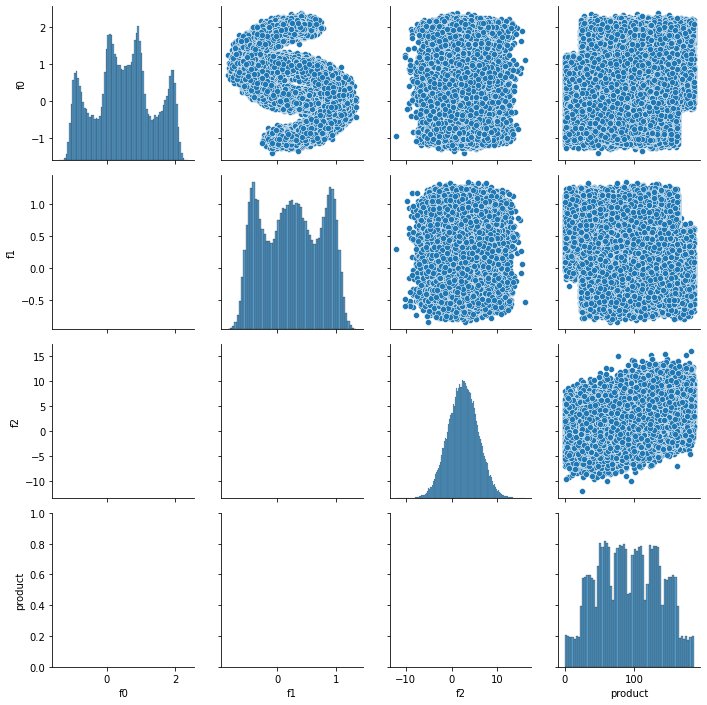

In [21]:
print('График отношения параметров месторождения 0')
g = sns.PairGrid(df_geo_data_0)
g.map_diag(sns.histplot)
g.map_upper(sns.scatterplot)
plt.show()

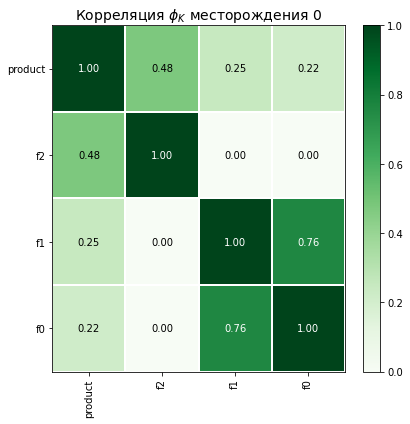

In [22]:
interval_cols = ['f0', 'f1', 'f2', 'product']
phik_overview = phik_matrix(df_geo_data_0, interval_cols=interval_cols)
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'Корреляция $\phi_K$ месторождения 0',
    fontsize_factor=1.0,
    figsize=(6, 6)
)

График отношения параметров месторождения 1


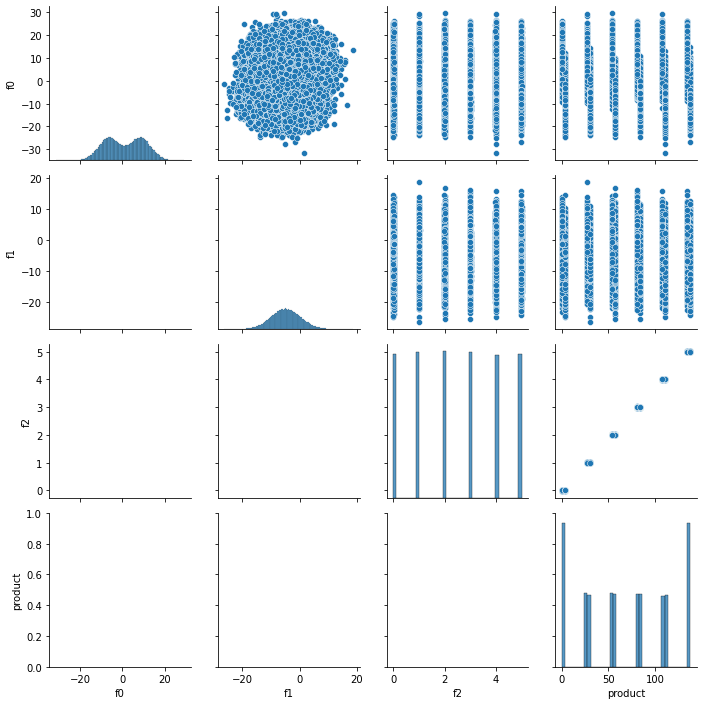

In [23]:
print('График отношения параметров месторождения 1')
g = sns.PairGrid(df_geo_data_1)
g.map_diag(sns.histplot)
g.map_upper(sns.scatterplot)
plt.show()

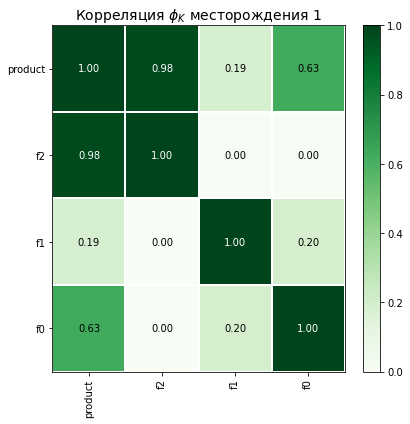

In [24]:
phik_overview = phik_matrix(df_geo_data_1, interval_cols=interval_cols)
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'Корреляция $\phi_K$ месторождения 1',
    fontsize_factor=1.0,
    figsize=(6, 6)
)

График отношения параметров месторождения 2


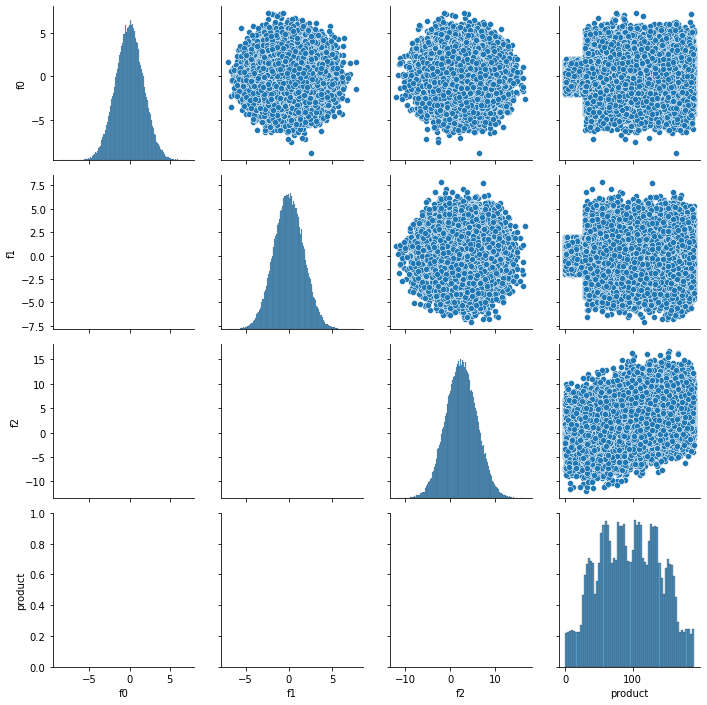

In [25]:
print('График отношения параметров месторождения 2')
g = sns.PairGrid(df_geo_data_2)
g.map_diag(sns.histplot)
g.map_upper(sns.scatterplot)
plt.show()

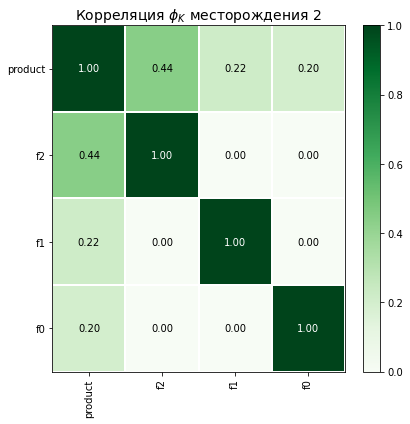

In [26]:
phik_overview = phik_matrix(df_geo_data_2, interval_cols=interval_cols)
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'Корреляция $\phi_K$ месторождения 2',
    fontsize_factor=1.0,
    figsize=(6, 6)
)

Данные месторождения из файла geo_data_1 выглядят некорректными: значения дискретны, хотя должны быть непрерывными; есть утечка целевого признака (между f2 и product корреляция = 0,98, прямая зависимость значений видна и на графике).

Данные месторождений из файлов geo_data_0 и geo_data_2 выглядят лучше, признаки имеют нормальные распределения, есть средний уровень корреляции f-признаков с целевым product.

### Подготовка данных

In [27]:
num_columns = ['f0', 'f1', 'f2']

In [28]:
data_preprocessor = ColumnTransformer(
    [
     ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])

In [29]:
pipe_final

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['f0', 'f1', 'f2'])])),
                ('models', LinearRegression())])

Функция разбивки данных и обучения моделей для каждого региона:

In [30]:
def region_model_train_predict(geo_data):
    X_train, X_test, y_train, y_test = train_test_split(
        geo_data.drop(['product'], axis=1),
        geo_data['product'],
        test_size = TEST_SIZE,
        random_state = RANDOM_STATE)
    
    pipe_final.fit(X_train, y_train)
    y_test_pred = pipe_final.predict(X_test) #получение предсказаний
    region_product_mean = y_test_pred.mean() #средний запас предсказанного сырья
    region_rmse = RMSE(y_test, y_test_pred)  #значение RMSE
    
    return y_test, y_test_pred, region_product_mean, region_rmse

## Обучение и проверка модели

In [32]:
y_test0, y_test_pred0, region_0_product_mean, region_0_rmse = region_model_train_predict(df_geo_data_0)
print('Средний запас предсказанного сырья для модели месторождения 0:', round(region_0_product_mean, 3), 'тыс. баррелей')
print('Значение RMSE для модели месторождения 0:', round(region_0_rmse, 3))

Средний запас предсказанного сырья для модели месторождения 0: 92.523 тыс. баррелей
Значение RMSE для модели месторождения 0: 37.948


In [33]:
y_test1, y_test_pred1, region_1_product_mean, region_1_rmse = region_model_train_predict(df_geo_data_1)
print('Средний запас предсказанного сырья для модели месторождения 1:', round(region_1_product_mean, 3), 'тыс. баррелей')
print('Значение RMSE для модели месторождения 1:', round(region_1_rmse, 3))

Средний запас предсказанного сырья для модели месторождения 1: 68.89 тыс. баррелей
Значение RMSE для модели месторождения 1: 0.891


In [34]:
y_test2, y_test_pred2, region_2_product_mean, region_2_rmse = region_model_train_predict(df_geo_data_2)
print('Средний запас предсказанного сырья для модели месторождения 2:', round(region_2_product_mean, 3), 'тыс. баррелей')
print('Значение RMSE для модели месторождения 2:', round(region_2_rmse, 3))

Средний запас предсказанного сырья для модели месторождения 2: 95.054 тыс. баррелей
Значение RMSE для модели месторождения 2: 40.377


Данные месторождения 1 (из файла df_geo_data_1), видимо, имеют какую-то ошибку: данные имеют дискретный тип, модель линейной регрессии, обученная на данных данного месторождения имеют наибольший RMSE (корень среднеквадратичной ошибки) и наименьшее значение среднего предсказанного сырья.

По значению RMSE лучше оказалась модель для месторождения 0, наибольшее значение среднего предсказанного сырья у местородения 2.

## Подготовка к расчёту прибыли

In [36]:
budget = 10_000_000_000
revenue_per_barrel = 450_000

full_set = 500
selected_set = 200

In [37]:
product_values_0 = pd.DataFrame(y_test0, columns=['product'])
product_values_0['predict'] = y_test_pred0
product_values_0

,product,predict
id,,
ZATXX,69.975177,84.400433
6Tuho,39.285382,112.347064
Z1TQB,157.374842,107.832824
FjWOi,150.032438,109.839570
tdiqP,138.691509,98.742712
...,...,...
iDZOF,104.090173,90.742862
FMTSY,159.943052,141.672357
X5qKS,151.169769,128.135075


In [38]:
product_values_1 = pd.DataFrame(y_test1, columns=['product'])
product_values_1['predict'] = y_test_pred1
product_values_1

,product,predict
id,,
kQNOq,57.085625,56.114807
9V0rU,30.132364,29.080020
jTdPe,107.813044,108.862828
i2kKN,84.038886,83.131104
uffjT,3.179103,3.971350
...,...,...
kOuY5,110.992147,108.580391
RGmt0,84.038886,83.571196
6po06,53.906522,54.185358


In [39]:
product_values_2 = pd.DataFrame(y_test2, columns=['product'])
product_values_2['predict'] = y_test_pred2
product_values_2

,product,predict
id,,
54PWv,13.050141,64.457377
86FlI,85.932473,99.822457
xcpmi,13.371628,78.605238
LSvdZ,114.574265,97.099947
TZZNB,39.913354,87.620231
...,...,...
vzHiB,187.469700,139.757871
5E0dP,161.708696,136.427929
wMOOp,67.354772,121.797204


In [40]:
product_values_0.describe()

,product,predict
count,25000.000000,25000.000000
mean,92.388268,92.523200
std,44.553368,23.328901
min,0.004022,-2.560316
25%,56.149153,76.618014
50%,91.456311,92.582145
75%,128.809332,108.443737
max,185.364347,195.098567


In [41]:
product_values_1.describe()

,product,predict
count,25000.000000,25000.000000
mean,68.889887,68.890345
std,46.056470,46.039808
min,0.000000,-1.894766
25%,26.953261,28.532883
50%,57.085625,58.435062
75%,110.992147,109.394530
max,137.945408,140.359187


In [42]:
product_values_2.describe()

,product,predict
count,25000.000000,25000.000000
mean,94.852687,95.054448
std,44.961452,19.783014
min,0.000000,13.996587
25%,59.283357,81.729037
50%,94.651224,95.039452
75%,130.647449,108.552806
max,190.011722,176.745314


In [43]:
print(f'Достаточный объём сырья для безубыточной разработки новой скважины: \
{round(budget / selected_set / revenue_per_barrel, 2)} тыс. баррелей на скважину')

Достаточный объём сырья для безубыточной разработки новой скважины: 111.11 тыс. баррелей на скважину


На всех 3 месторождениях среднее значение добываемого сырья на скважине меньше значения 111 тыс. баррелей, необходимого для безубыточной разработки. Из-за этого нельзя выбрать любые скважины для старта разработки.

## Расчёт прибыли и рисков 

Функция расчёта прибыли:

In [44]:
def revenue(product_values, count):
    product_values_sorted = product_values.sort_values('predict', ascending=False)
    selected = product_values_sorted['product'][:count]
    return selected.sum() * revenue_per_barrel - budget

Расчёт риска убытка и прибыль для каждого региона:

In [45]:
regions = [product_values_0, product_values_1, product_values_2]

In [46]:
for region_product_values in regions:
    values = []
    for i in range(1000):
        subsample = region_product_values.sample(n=full_set, replace=True, random_state=state)
        values.append(revenue(subsample, selected_set))

    values = pd.Series(values)
    lower = values.quantile(0.025)
    upper = values.quantile(0.975)
    risks_count = 0
    for i in values:
        if i < 0:
            risks_count += 1

    mean = values.mean()
    print(f'Средняя прибыль: {round(mean, 2)} руб.')
    print(f'95%-ый доверительный интервал: {round(lower, 2)} - {round(upper, 2)}')
    print(f'Вероятность убытков: {risks_count / 10}%') #кол-во отриц. прибыли / 1000(кол-во значений распределения) * 100(%)
    print('-----------------------------------------------')

Средняя прибыль: 422422812.08 руб.
95%-ый доверительный интервал: -146903745.02 - 935590063.99
Вероятность убытков: 5.7%
-----------------------------------------------
Средняя прибыль: 456933568.2 руб.
95%-ый доверительный интервал: 79083327.98 - 860143737.8
Вероятность убытков: 1.0%
-----------------------------------------------
Средняя прибыль: 344222797.67 руб.
95%-ый доверительный интервал: -167092185.77 - 841056999.82
Вероятность убытков: 10.5%
-----------------------------------------------


## Вывод

Под условие вероятности убытков меньше 2,5% подходит только месторождение, данные по которому были получены в файле geo_data_1. Это же месторождение имеет и наибольшее значение средней прибыли (около 460 млн. руб.). Но данные данного месторождения выглядят некорректными: значения дискретны, хотя должны быть непрерывными; есть утечка целевого признака (между f2 и product корреляция = 0,98, прямая зависимость значений видна и на графике). Стоит проверить корректность данных данного месторождения и выполнить проверку на вновь предоставленных значениях, если это возможно.